# Fetch and Analyze Baseline Metrics

This notebook fetches Prometheus metrics for your Kubernetes cluster and prepares data for AI model training.

In [1]:
# Import Libraries
import requests
import pandas as pd
from datetime import datetime, timedelta
import os

# Configuration
PROM_URL = "http://localhost:9090"  # Update if using port-forward or different IP
STEP = "15s"  # Resolution of your data
LOOKBACK_HOURS = 1  # Last 1 hour

# Define the metric queries
QUERIES = {
    "cpu_usage": 'sum(rate(container_cpu_usage_seconds_total{pod=~"prime-service-deployment-.*",container!=""}[1m]))',
    "mem_usage_mb": 'sum(container_memory_usage_bytes{pod=~"prime-service-deployment-.*",container!=""}) / (1024*1024)',
    "app_rps_1m": 'sum(rate(http_request_duration_seconds_count[1m]))',
    "ingress_rps_1m": 'sum(rate(nginx_ingress_controller_requests[1m]))',
    "rps_diff_1m": 'abs(sum(rate(http_request_duration_seconds_count[1m])) - sum(rate(nginx_ingress_controller_requests[1m])))',
    "app_p99_latency": 'histogram_quantile(0.99, sum by (le) (rate(http_request_duration_seconds_bucket{service="prime-service"}[1m])))',
    "ingress_p99_latency": 'histogram_quantile(0.99, sum by (le) (rate(nginx_ingress_controller_request_duration_seconds_bucket{ingress="ingress-backend"}[1m])))',
    "nginx_active_conn": 'sum(nginx_ingress_controller_nginx_process_connections{state=~"active"})',
    "nginx_writing_conn": 'sum(nginx_ingress_controller_nginx_process_connections{state=~"writing"})',
    "latency_gap": 'abs(histogram_quantile(0.99, sum by (le) (rate(http_request_duration_seconds_bucket{service="prime-service"}[1m]))) - histogram_quantile(0.95, sum by (le) (rate(nginx_ingress_controller_request_duration_seconds_bucket{ingress="ingress-backend"}[1m]))))'
}

print("Configuration loaded!")

Configuration loaded!


In [2]:
# Define Functions

def fetch_metric_range(query, start, end, step):
    """Fetch metric data from Prometheus"""
    endpoint = f"{PROM_URL}/api/v1/query_range"
    params = {
        "query": query,
        "start": start,
        "end": end,
        "step": step
    }
    response = requests.get(endpoint, params=params)
    response.raise_for_status()
    data = response.json()
    
    # Process results into a dictionary of {timestamp: value}
    results = {}
    if data['data']['result']:
        for timestamp, value in data['data']['result'][0]['values']:
            results[int(timestamp)] = float(value)
    return results

def fetch_all_metrics(lookback_hours=LOOKBACK_HOURS):
    """Fetch all metrics for the specified lookback period"""
    end_time = int(datetime.now().timestamp())
    start_time = int((datetime.now() - timedelta(hours=lookback_hours)).timestamp())
    
    print(f"Fetching data from {datetime.fromtimestamp(start_time)} to {datetime.fromtimestamp(end_time)}...")
    
    all_data = {}
    
    for name, query in QUERIES.items():
        print(f"Fetching: {name}")
        try:
            all_data[name] = fetch_metric_range(query, start_time, end_time, STEP)
        except Exception as e:
            print(f"Error fetching {name}: {e}")
    
    # Convert to DataFrame with aligned timestamps
    df = pd.DataFrame(all_data)
    df.index = pd.to_datetime(df.index, unit='s')
    df = df.sort_index()
    
    # Fill missing values
    df = df.interpolate(method='linear').fillna(0)
    
    return df

print("Functions defined!")

Functions defined!


In [3]:
# Fetch Metrics and Save to CSV

# Fetch all metrics
df = fetch_all_metrics(LOOKBACK_HOURS)

# Display info

print(f"\n✅ Data fetched successfully!")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nFirst few rows:")
print(df.head())

# Save to CSV
filename = f"k8s_metrics_baseline_{datetime.now().strftime('%Y%m%d_%H%M')}.csv"
df.to_csv(filename)
print(f"\n💾 Dataset saved to: {filename}")

Fetching data from 2026-04-06 22:44:05 to 2026-04-06 23:44:05...
Fetching: cpu_usage
Error fetching cpu_usage: HTTPConnectionPool(host='localhost', port=9090): Max retries exceeded with url: /api/v1/query_range?query=sum%28rate%28container_cpu_usage_seconds_total%7Bpod%3D~%22prime-service-deployment-.%2A%22%2Ccontainer%21%3D%22%22%7D%5B1m%5D%29%29&start=1775490245&end=1775493845&step=15s (Caused by NewConnectionError("HTTPConnection(host='localhost', port=9090): Failed to establish a new connection: [Errno 111] Connection refused"))
Fetching: mem_usage_mb
Error fetching mem_usage_mb: HTTPConnectionPool(host='localhost', port=9090): Max retries exceeded with url: /api/v1/query_range?query=sum%28container_memory_usage_bytes%7Bpod%3D~%22prime-service-deployment-.%2A%22%2Ccontainer%21%3D%22%22%7D%29+%2F+%281024%2A1024%29&start=1775490245&end=1775493845&step=15s (Caused by NewConnectionError("HTTPConnection(host='localhost', port=9090): Failed to establish a new connection: [Errno 111] Conn

In [4]:
# (Optional) Explore the Data

# Display summary statistics
print("Summary Statistics:")
print(df.describe())

# Check for missing values
print(f"\nMissing values:\n{df.isnull().sum()}")

Summary Statistics:


ValueError: Cannot describe a DataFrame without columns

# Plot the data 

In [5]:
df = pd.read_csv("./data/baseline/unlimited.csv")
df.rename(columns={"Unnamed: 0": "time"}, inplace=True)

In [6]:
# read csv
df.head()

,time,cpu_usage,mem_usage_mb,app_rps_1m,ingress_rps_1m,rps_diff_1m,app_p99_latency,ingress_p99_latency,nginx_active_conn,nginx_writing_conn,latency_gap
0,2026-04-06 14:53:11,0.113814,31.554688,10.436364,9.900000,0.536364,0.0495,0.049265,12.0,1.0,0.004668
1,2026-04-06 14:53:26,0.113390,33.109375,10.527273,9.900000,0.627273,0.0495,0.049265,12.0,1.0,0.004668
2,2026-04-06 14:53:41,0.146932,32.031250,11.763636,10.933333,0.830303,0.0495,0.090857,17.0,1.0,0.002804
3,2026-04-06 14:53:56,0.166666,31.699219,13.254545,10.933333,2.321212,0.0495,0.090857,17.0,1.0,0.002804
4,2026-04-06 14:54:11,0.185696,31.582031,14.381818,15.333333,0.951515,0.0495,0.049540,17.0,1.0,0.005247


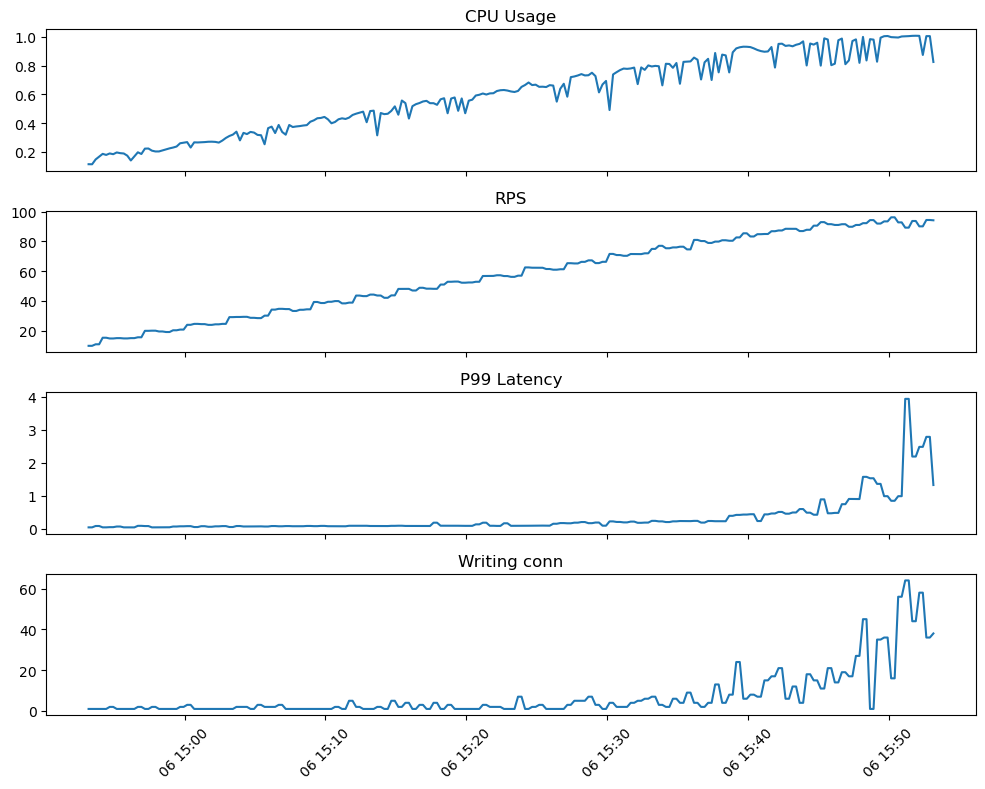

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("./data/baseline/unlimited.csv")
df.rename(columns={"Unnamed: 0": "time"}, inplace=True)
df["time"] = pd.to_datetime(df["time"])

fig, ax = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

ax[0].plot(df["time"], df["cpu_usage"])
ax[0].set_title("CPU Usage")

ax[1].plot(df["time"], df["ingress_rps_1m"])
ax[1].set_title("RPS")

ax[2].plot(df["time"], df["ingress_p99_latency"])
ax[2].set_title("P99 Latency")

ax[3].plot(df["time"], df["nginx_writing_conn"])
ax[3].set_title("Writing conn")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()